<a href="https://colab.research.google.com/github/ghadirchhade/Master-Thesis/blob/main/E02_w_o_tiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
!pip install -q torch torchvision

In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# facebook/sam3 is gated on the Hub -> you must accept the license at
# https://huggingface.co/facebook/sam3 with the account whose token you use below.
!pip install -q -U transformers accelerate huggingface_hub supervision

from huggingface_hub import login
login()  # paste your HF token (needs access to facebook/sam3)

print("Transformers SAM3 dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.8 MB/s eta 0:00:00
Transformers SAM3 dependencies installed.


In [ ]:
import os
import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import supervision as sv

from transformers import Sam3Model, Sam3Processor

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam3_model = Sam3Model.from_pretrained("facebook/sam3", device_map="auto")
sam3_model.eval()

sam3_processor = Sam3Processor.from_pretrained("facebook/sam3")

print("HF transformers SAM3 model + processor loaded.")
print("Model device:", next(sam3_model.parameters()).device)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

HF transformers SAM3 model + processor loaded.
Model device: cuda:0


In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/images/20230426_Wallenwil/DJI_20230426110736_0035.JPG"
LABEL_PATH = "/content/drive/MyDrive/datasets/AGS_Multi_Rumex/annotations_yolo/DJI_20230426110736_0035.txt"
RUMEX_CLASS_ID = 0

image = Image.open(IMAGE_PATH).convert("RGB")
img_w, img_h = image.size
print(f"Image size: {image.size}")

# Resize a copy for SAM3 inference only. This keeps the mask upsampling step
# inside post_process_instance_segmentation cheap (it upsamples to whatever
# size we feed the processor, not the full native drone-image resolution).
MAX_DIM = 1024

def resize_for_sam3(img, max_dim=MAX_DIM):
    w, h = img.size
    scale = max_dim / max(w, h)
    if scale >= 1:
        return img, 1.0
    new_w, new_h = int(w * scale), int(h * scale)
    return img.resize((new_w, new_h), Image.BILINEAR), scale

image_sam, sam_scale = resize_for_sam3(image)
print(f"SAM3 input size: {image_sam.size} (scale={sam_scale:.4f})")

Image size: (8192, 5460)
SAM3 input size: (1024, 682) (scale=0.1250)


In [ ]:
import matplotlib.font_manager as fm

font_path = fm.findfont("DejaVu Sans")
print(font_path)

/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


In [ ]:
# Load and display ALL ground-truth "rumex" (class id = 0) boxes on the input image,
# each labeled with its index, so we can pick one to use as the exemplar box below.
def load_yolo_boxes(label_path, img_width, img_height, class_id=0):
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            if cls != class_id:
                continue
            xc, yc, bw, bh = map(float, parts[1:5])
            xc, yc, bw, bh = xc * img_width, yc * img_height, bw * img_width, bh * img_height
            boxes.append([xc - bw / 2, yc - bh / 2, xc + bw / 2, yc + bh / 2])
    return np.array(boxes, dtype=np.float32)

gt_boxes = load_yolo_boxes(LABEL_PATH, img_w, img_h, class_id=RUMEX_CLASS_ID)
print(f"Loaded {len(gt_boxes)} GT box(es) with class id={RUMEX_CLASS_ID}.")

Loaded 57 GT box(es) with class id=0.


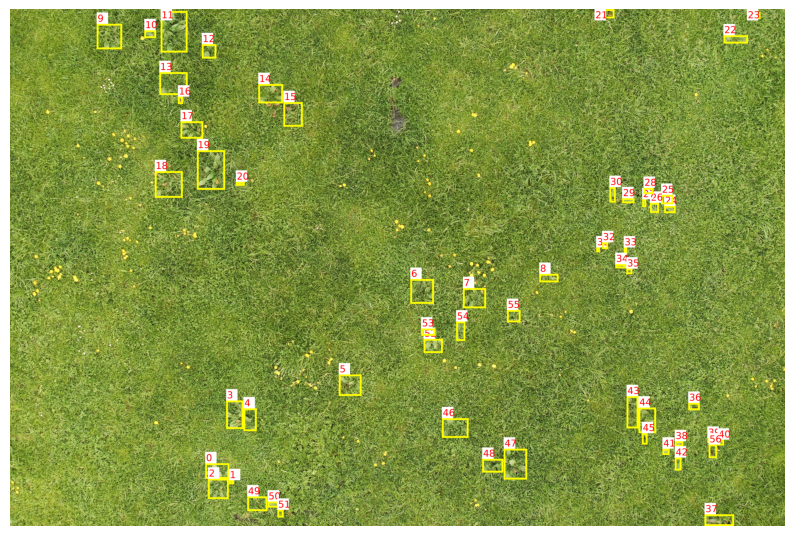

In [ ]:
#visualize all GT bboxes

gt_preview = image.copy()
draw = ImageDraw.Draw(gt_preview)

# Find available font
font_path = fm.findfont("DejaVu Sans")
font = ImageFont.truetype(font_path, 100)

for i, (x0, y0, x1, y1) in enumerate(gt_boxes):

    # Draw bounding box
    draw.rectangle([x0, y0, x1, y1],outline=(255, 255, 0),width=20)

    # Text position
    text_x = int(x0)
    text_y = max(0, int(y0)-120)

    # Background rectangle for label
    draw.rectangle([text_x, text_y, text_x+120, text_y+120],fill=(255, 255, 255))

    # Draw index
    draw.text((text_x+10, text_y+5),str(i),fill=(255, 0, 0),font=font)

plt.figure(figsize=(10,8))
plt.imshow(gt_preview)
plt.axis("off")
plt.show()

In [ ]:
# Select 3 positive exemplar boxes using their indices
exemplar_indices = [6, 29, 11]
assert len(exemplar_indices) == 3, "Please provide exactly 3 exemplar indices."

# Get bboxes from GT boxes
exemplar_boxes_fullres = [gt_boxes[idx].tolist() for idx in exemplar_indices]

# HF SAM3 box format: pixel-space [x1,y1,x2,y2], one entry per exemplar box
input_boxes_xyxy_fullres = [[float(c) for c in box] for box in exemplar_boxes_fullres]
input_boxes_xyxy = [[c * sam_scale for c in box] for box in input_boxes_xyxy_fullres]

print(f"Selected exemplar box indices: {exemplar_indices}")
print(f"Boxes xyxy (full-res, for display): {input_boxes_xyxy_fullres}")
print(f"Boxes xyxy (SAM3 input, scaled to image_sam): {input_boxes_xyxy}")

Selected exemplar box indices: [6, 29, 11]
Boxes xyxy (full-res, for display): [[4231.23486328125, 2851.010986328125, 4481.14306640625, 3113.529052734375], [6470.9931640625, 1998.468994140625, 6601.69482421875, 2051.1708984375], [1592.97705078125, 21.145999908447266, 1876.094970703125, 459.3320007324219]]
Boxes xyxy (SAM3 input, scaled to image_sam): [[528.9043579101562, 356.3763732910156, 560.1428833007812, 389.1911315917969], [808.8741455078125, 249.80862426757812, 825.2118530273438, 256.3963623046875], [199.12213134765625, 2.643249988555908, 234.51187133789062, 57.416500091552734]]


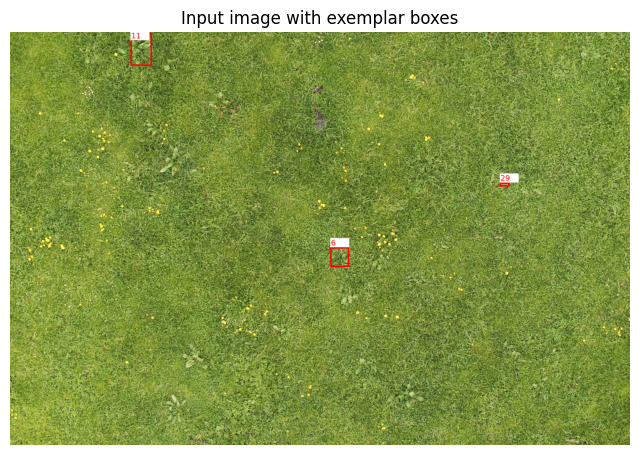

In [ ]:
# Select 3 positive exemplar boxes using their indices
exemplar_indices = [6, 29, 11]
assert len(exemplar_indices) == 3, "Please provide exactly 3 exemplar indices."

# Get bboxes from GT boxes
exemplar_boxes_fullres = [gt_boxes[idx].tolist() for idx in exemplar_indices]

# HF SAM3 box format: pixel-space [x1,y1,x2,y2], one entry per exemplar box
input_boxes_xyxy_fullres = [[float(c) for c in box] for box in exemplar_boxes_fullres]
input_boxes_xyxy = [[c * sam_scale for c in box] for box in input_boxes_xyxy_fullres]

print(f"Selected exemplar box indices: {exemplar_indices}")
print(f"Boxes xyxy (full-res, for display): {input_boxes_xyxy_fullres}")
print(f"Boxes xyxy (SAM3 input, scaled to image_sam): {input_boxes_xyxy}")

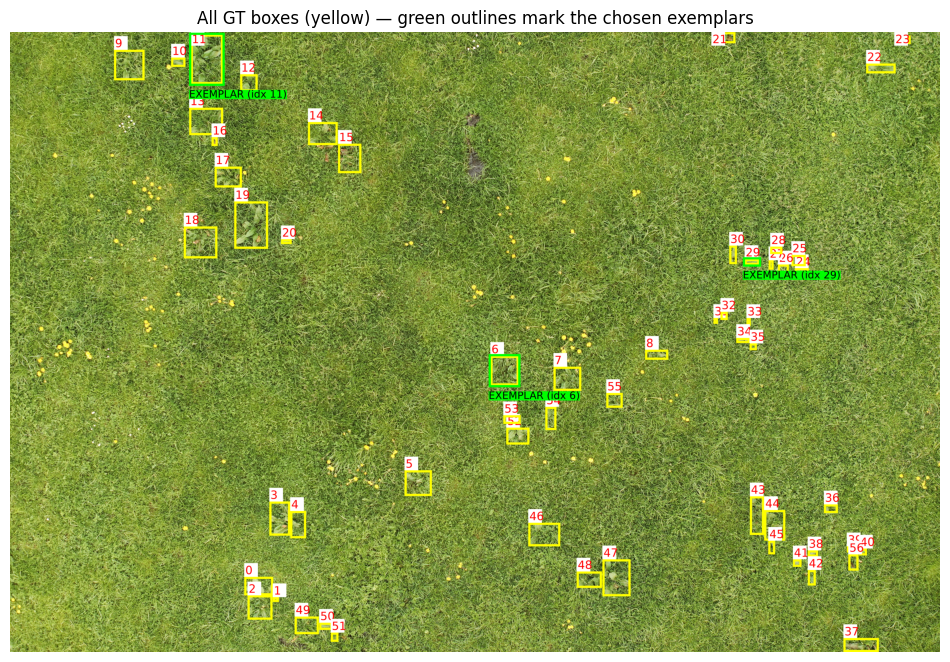

In [ ]:
# Show ALL GT boxes (yellow) with their indices, and separately highlight
# the chosen exemplar boxes (thicker green outline + "EXEMPLAR" label)
# so the original yellow GT box for each is still visible underneath.

exemplar_preview = image.copy()
draw = ImageDraw.Draw(exemplar_preview)

for i, (bx0, by0, bx1, by1) in enumerate(gt_boxes):
    draw.rectangle([bx0, by0, bx1, by1], outline=(255, 255, 0), width=20)
    text_x, text_y = int(bx0), max(0, int(by0) - 120)
    draw.rectangle([text_x, text_y, text_x + 120, text_y + 120], fill=(255, 255, 255))
    draw.text((text_x + 10, text_y + 5), str(i), fill=(255, 0, 0), font=font)

# Highlight the chosen exemplar boxes on top, without covering the yellow GT boxes
HIGHLIGHT_PAD = 15  # draw slightly outside the GT box so both outlines stay visible
label_font = ImageFont.truetype(font_path, 90)

for idx in exemplar_indices:
    ex_x0, ex_y0, ex_x1, ex_y1 = gt_boxes[idx]

    draw.rectangle(
        [ex_x0 - HIGHLIGHT_PAD, ex_y0 - HIGHLIGHT_PAD, ex_x1 + HIGHLIGHT_PAD, ex_y1 + HIGHLIGHT_PAD],
        outline=(0, 255, 0),
        width=20,
    )

    # "EXEMPLAR" label near the highlighted box
    label_text = f"EXEMPLAR (idx {idx})"
    label_x, label_y = int(ex_x0 - HIGHLIGHT_PAD), int(ex_y1 + HIGHLIGHT_PAD + 20)
    text_bbox = draw.textbbox((label_x, label_y), label_text, font=label_font)
    draw.rectangle(text_bbox, fill=(0, 255, 0))
    draw.text((label_x, label_y), label_text, fill=(0, 0, 0), font=label_font)

plt.figure(figsize=(12, 10))
plt.imshow(exemplar_preview)
plt.axis("off")
plt.title("All GT boxes (yellow) — green outlines mark the chosen exemplars")
plt.show()

In [ ]:
# input_boxes shape: [batch, num_boxes, 4]; input_boxes_labels shape: [batch, num_boxes]
input_boxes = [input_boxes_xyxy]           # 1 batch, 3 boxes
input_boxes_labels = [[1, 1, 1]]           # 1 = positive box (exemplar) for each of the 3 boxes

inputs = sam3_processor(
    images=image_sam,
    input_boxes=input_boxes,
    input_boxes_labels=input_boxes_labels,
    return_tensors="pt",
).to(sam3_model.device)

with torch.no_grad():
    outputs = sam3_model(**inputs)

results = sam3_processor.post_process_instance_segmentation(
    outputs,
    threshold=0.3,   #confidence threshold
    mask_threshold=0.5,
    target_sizes=inputs.get("original_sizes").tolist(),
)[0]

# Already in absolute pixel coords for the ORIGINAL image — no manual rescaling needed
pred_masks = results["masks"]
pred_boxes = results["boxes"]
pred_scores = results["scores"]

print(f"SAM3 (HF transformers) returned {len(pred_boxes)} final mask(s).")

SAM3 (HF transformers) returned 41 final mask(s).


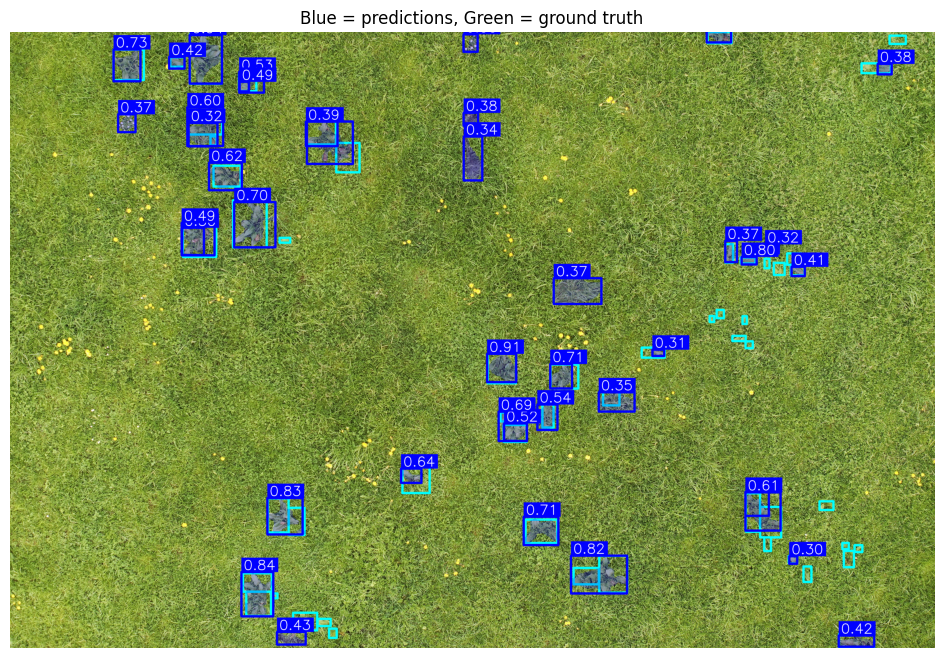

In [ ]:
import cv2

# Visualize predictions (blue) vs ground truth (green) — one fixed color per set
image_np = np.array(image)

def to_numpy(x):
    if torch.is_tensor(x):
        if x.dtype in (torch.bfloat16, torch.float16):
            x = x.float()  # upcast to float32, numpy-compatible
        return x.detach().cpu().numpy()
    if isinstance(x, (list, tuple)):
        if len(x) > 0 and torch.is_tensor(x[0]):
            x = [t.float() if t.dtype in (torch.bfloat16, torch.float16) else t for t in x]
            return torch.stack([t.detach().cpu() for t in x]).numpy()
        return np.array(x)
    return np.array(x)


pred_boxes_np = to_numpy(pred_boxes)
pred_scores_np = to_numpy(pred_scores)
pred_masks_np = to_numpy(pred_masks)

# Predicted boxes came back in image_sam's pixel coords -> scale up to match
# gt_boxes / the full-res display image.
if len(pred_boxes_np) > 0:
    pred_boxes_np = pred_boxes_np / sam_scale

# Predicted masks also came back at image_sam's resolution -> upsample each one
# to the full-res image size so they line up with gt_boxes / image_np.
full_res_masks = None
if len(pred_masks_np) > 0:
    full_res_masks = np.zeros((len(pred_masks_np), img_h, img_w), dtype=bool)
    for i, m in enumerate(pred_masks_np):
        m_resized = cv2.resize(
            m.astype(np.uint8),
            (img_w, img_h),
            interpolation=cv2.INTER_NEAREST,
        )
        full_res_masks[i] = m_resized.astype(bool)

pred_detections = sv.Detections(
    xyxy=pred_boxes_np, #predicted boxes
    confidence=pred_scores_np,  #predicted confidence scores
    class_id=np.zeros(len(pred_scores_np), dtype=int), # class_id=0
    mask=full_res_masks,            # predicted masks, full-res
)
gt_detections = sv.Detections(
    xyxy=gt_boxes, #GT boxes
    class_id=np.zeros(len(gt_boxes), dtype=int), #GT ids =0 (1 class)
)

#colors
red_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX, thickness=20)
yellow_annotator = sv.BoxAnnotator(color=sv.Color.YELLOW, color_lookup=sv.ColorLookup.INDEX, thickness=20)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX, opacity=0.25)

label_annotator = sv.LabelAnnotator(
    color=sv.Color.RED,
    text_color=sv.Color.WHITE,
    text_scale=4.0,
    text_thickness=6,
    text_padding=20,
)

annotated = yellow_annotator.annotate(scene=image_np.copy(), detections=gt_detections)     # GT boxes
annotated = mask_annotator.annotate(scene=annotated, detections=pred_detections)           # predicted masks
annotated = red_annotator.annotate(scene=annotated, detections=pred_detections)            # predicted boxes
annotated = label_annotator.annotate(
    scene=annotated, detections=pred_detections,
    labels=[f"{s:.2f}" for s in pred_scores_np],
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Blue = predictions, Green = ground truth")
plt.show()

In [ ]:
# Compute mAP50 for this single image for detection evaluation
#detection evaluation metric that measures how well your model detects objects when a prediction is considered correct if its Intersection over Union (IoU) with the ground truth is at least 0.5.
from supervision.metrics import MeanAveragePrecision

map_metric = MeanAveragePrecision()
result = map_metric.update([pred_detections], [gt_detections]).compute()

print(f"mAP50: {result.map50:.4f}")

mAP50: 0.2596


In [ ]:
# Compute Precision, Recall, and IoU for this single image (box-based matching)

def compute_iou_matrix(boxes1, boxes2):
    #IoU between every pair of boxes in boxes1 (N,4) and boxes2 (M,4), xyxy format
    if len(boxes1) == 0 or len(boxes2) == 0: #If there are no predictions or no GT boxes, return an empty IoU matrix.
        return np.zeros((len(boxes1), len(boxes2)))

    #Find the overlapping rectangle between every prediction and every GT.
    x1 = np.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = np.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = np.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = np.minimum(boxes1[:, None, 3], boxes2[None, :, 3])

    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    inter_area = inter_w * inter_h

    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2[None, :] - inter_area

    return np.where(union_area > 0, inter_area / union_area, 0.0)


IOU_THRESHOLD = 0.5

iou_matrix = compute_iou_matrix(pred_boxes_np, gt_boxes)  # shape [num_preds, num_gt]

num_preds = len(pred_boxes_np)
num_gt = len(gt_boxes)

matched_gt = set()
true_positives = 0
matched_ious = []  # IoU of each matched (TP) prediction, for the "mean IoU" figure

# Greedy matching: go through predictions sorted by confidence (highest first),
# match each to its best still-unmatched GT box if IoU clears the threshold.
pred_order = np.argsort(-pred_scores_np) if num_preds > 0 else []

for pred_idx in pred_order:
    if num_gt == 0:
        break
    best_gt_idx = np.argmax(iou_matrix[pred_idx])
    best_iou = iou_matrix[pred_idx, best_gt_idx]
    if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
        matched_gt.add(best_gt_idx)
        true_positives += 1
        matched_ious.append(best_iou)

false_positives = num_preds - true_positives
false_negatives = num_gt - true_positives

precision = true_positives / num_preds if num_preds > 0 else 0.0
recall = true_positives / num_gt if num_gt > 0 else 0.0

#When SAM3 successfully detects a Rumex plant, how accurate is the bounding box??
#matched_ious contains only true positive predictions.
mean_iou_matched = float(np.mean(matched_ious)) if matched_ious else 0.0

# Mean IoU over ALL GT boxes (It treats missed objects as IoU = 0.), a stricter overall figure
mean_iou_all_gt = float(np.sum(matched_ious) / num_gt) if num_gt > 0 else 0.0

print(f"IoU threshold: {IOU_THRESHOLD}")
print(f"Num predictions: {num_preds} | Num GT boxes: {num_gt}")
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Mean IoU (matched pairs only): {mean_iou_matched:.4f}")
print(f"Mean IoU (over all GT boxes):  {mean_iou_all_gt:.4f}")

IoU threshold: 0.5
Num predictions: 41 | Num GT boxes: 57
True Positives:  21
False Positives: 20
False Negatives: 36
Precision: 0.5122
Recall:    0.3684
Mean IoU (matched pairs only): 0.7407
Mean IoU (over all GT boxes):  0.2729
